# SIMULACIONES

Creo un video con una animación de la matriz de matriz.txt para ver las partículas.

In [11]:
### PARA GIF ########################################


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import imageio.v2 as imageio

# =========================================================
# PARÁMETROS
# =========================================================
nombre_archivo = "MATRIZ.txt"
nombre_video = "evolucion_matriz.gif"
fps = 5

# =========================================================
# FUNCIÓN PARA LEER EL FICHERO
# =========================================================
def leer_matrices(nombre_archivo):
    with open(nombre_archivo, "r") as f:
        lineas = f.readlines()

    matrices = []
    bloque_actual = []

    for linea in lineas:
        linea = linea.strip()

        if linea == "":
            if bloque_actual:
                matriz = []
                for fila in bloque_actual:
                    valores = [int(x) for x in fila.split()]
                    matriz.append(valores)
                matrices.append(np.array(matriz))
                bloque_actual = []
        else:
            bloque_actual.append(linea)

    if bloque_actual:
        matriz = []
        for fila in bloque_actual:
            valores = [int(x) for x in fila.split()]
            matriz.append(valores)
        matrices.append(np.array(matriz))

    return matrices

# =========================================================
# LEER MATRICES
# =========================================================
matrices = leer_matrices(nombre_archivo)

if len(matrices) == 0:
    raise ValueError("No se ha encontrado ninguna matriz en el archivo.")

n_filas, n_columnas = matrices[0].shape

# =========================================================
# COLORES
# =========================================================
cmap = ListedColormap(["white", "blue", "red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# =========================================================
# GUARDAR VÍDEO
# =========================================================
with imageio.get_writer(nombre_video, fps=fps) as writer:
    for contador, matriz in enumerate(matrices):
        fig, ax = plt.subplots(figsize=(6, 6))

        ax.imshow(matriz, cmap=cmap, norm=norm)

        ax.set_xticks(np.arange(-0.5, n_columnas, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n_filas, 1), minor=True)
        ax.grid(which="minor", color="black", linestyle="-", linewidth=1)

        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_title(f"Paso = {contador}", fontsize=16)

        plt.tight_layout()

        fig.canvas.draw()
        imagen = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        imagen = imagen.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        imagen = imagen[:, :, :3]

        writer.append_data(imagen)
        plt.close(fig)

print(f"Vídeo guardado como: {nombre_video}")

Vídeo guardado como: evolucion_matriz.gif


In [7]:
### PARA VIDEO ##########################

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import cv2

# =========================================================
# PARÁMETROS
# =========================================================
nombre_archivo = "MATRIZ.txt"
nombre_video = "evolucion_matriz.mp4"
fps = 10

# =========================================================
# FUNCIÓN PARA LEER LAS MATRICES DEL ARCHIVO
# =========================================================
def leer_matrices(nombre_archivo):
    with open(nombre_archivo, "r") as f:
        lineas = f.readlines()

    matrices = []
    bloque = []

    for linea in lineas:
        linea = linea.strip()

        if linea == "":
            if bloque:
                matriz = []
                for fila in bloque:
                    valores = [int(x) for x in fila.split()]
                    matriz.append(valores)
                matrices.append(np.array(matriz))
                bloque = []
        else:
            bloque.append(linea)

    # Por si el archivo no termina con línea vacía
    if bloque:
        matriz = []
        for fila in bloque:
            valores = [int(x) for x in fila.split()]
            matriz.append(valores)
        matrices.append(np.array(matriz))

    return matrices

# =========================================================
# LEER MATRICES
# =========================================================
matrices = leer_matrices(nombre_archivo)

if len(matrices) == 0:
    raise ValueError("No se ha encontrado ninguna matriz en el archivo.")

n_filas, n_columnas = matrices[0].shape

# =========================================================
# MAPA DE COLORES
# 0 -> blanco
# 1 -> azul
# 2 -> rojo
# =========================================================
cmap = ListedColormap(["white", "blue", "red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# =========================================================
# CREAR FIGURA
# =========================================================
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

ancho = int(fig.get_figwidth() * fig.dpi)
alto = int(fig.get_figheight() * fig.dpi)

# =========================================================
# CREAR EL ESCRITOR DE VÍDEO
# =========================================================
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video = cv2.VideoWriter(nombre_video, fourcc, fps, (ancho, alto))

if not video.isOpened():
    raise ValueError("No se pudo abrir el escritor de vídeo. Prueba a instalar opencv correctamente o usar otro codec.")

# =========================================================
# GENERAR LOS FRAMES
# =========================================================
for contador, matriz in enumerate(matrices):
    ax.clear()

    ax.imshow(matriz, cmap=cmap, norm=norm)

    # Cuadrícula
    ax.set_xticks(np.arange(-0.5, n_columnas, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_filas, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)

    # Quitamos numeritos de los ejes
    ax.set_xticks([])
    ax.set_yticks([])

    # Título con el paso
    ax.set_title(f"Paso = {contador}", fontsize=16)

    plt.tight_layout()

    # Convertir la figura de matplotlib a imagen
    fig.canvas.draw()
    imagen = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    imagen = imagen.reshape(alto, ancho, 4)

    # Pasar de RGBA a BGR para OpenCV
    frame_bgr = cv2.cvtColor(imagen, cv2.COLOR_RGBA2BGR)

    # Escribir frame en el vídeo
    video.write(frame_bgr)

# =========================================================
# CERRAR TODO
# =========================================================
video.release()
plt.close(fig)

print(f"Vídeo guardado como: {nombre_video}")

Vídeo guardado como: evolucion_matriz.mp4


### Código para plotear la densidad y la presión

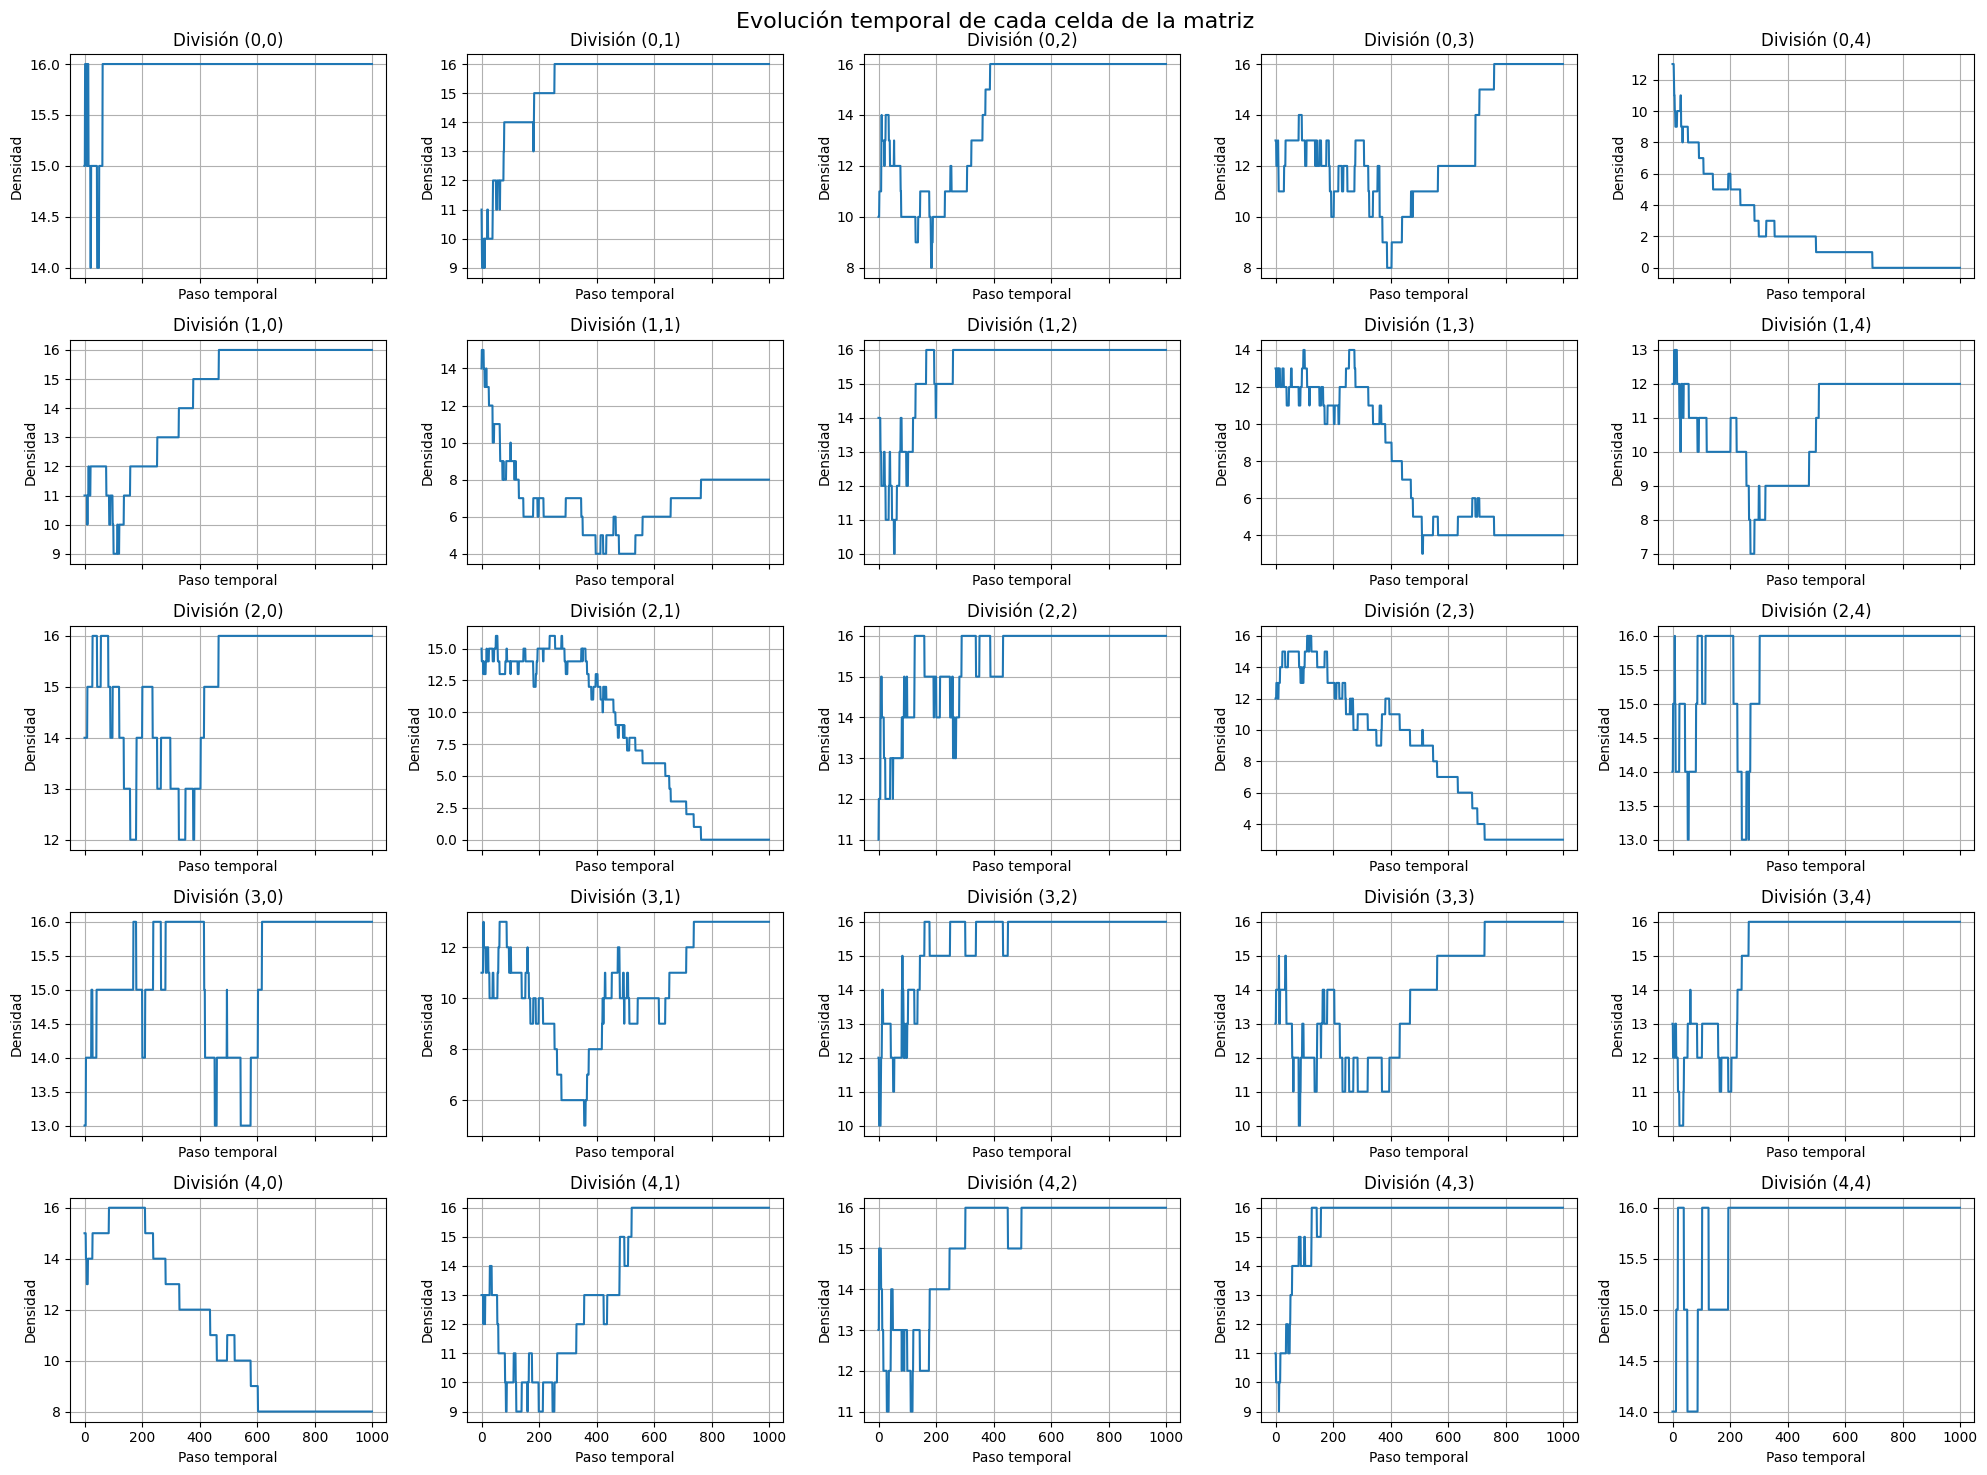

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ===== LEER EL FICHERO =====
with open("densidad.txt", "r", encoding="utf-8") as f:
    texto = f.read().strip()

# ===== SEPARAR LOS PASOS TEMPORALES =====
# Cada bloque separado por una línea en blanco es una matriz en un instante de tiempo
bloques = texto.split("\n\n")

matrices = []

for bloque in bloques:
    lineas = bloque.strip().split("\n")
    matriz = []

    for linea in lineas:
        fila = list(map(float, linea.split()))
        matriz.append(fila)

    matrices.append(matriz)

# Convertimos a array de numpy
datos = np.array(matrices)

# dimensiones: (tiempo, filas, columnas)
num_tiempos = datos.shape[0]
num_filas = datos.shape[1]
num_columnas = datos.shape[2]

# Vector temporal
t = np.arange(num_tiempos)

# ===== HACER LA FIGURA =====
fig, axes = plt.subplots(num_filas, num_columnas, figsize=(4*num_columnas, 3*num_filas), sharex=True)

# Por si alguna vez la matriz fuese de 1 fila o 1 columna
if num_filas == 1 and num_columnas == 1:
    axes = np.array([[axes]])
elif num_filas == 1:
    axes = axes[np.newaxis, :]
elif num_columnas == 1:
    axes = axes[:, np.newaxis]

# ===== PLOT DE CADA CELDA =====
for i in range(num_filas):
    for j in range(num_columnas):
        axes[i, j].plot(t, datos[:, i, j])
        axes[i, j].set_title(f"División ({i},{j})")
        axes[i, j].set_xlabel("Paso temporal")
        axes[i, j].set_ylabel("Densidad")
        axes[i, j].grid(True)

fig.suptitle("Evolución temporal de cada celda de la matriz", fontsize=16)
fig.tight_layout()

# Guardar imagen
plt.savefig("evolucion_densidad_celdas.png", dpi=200, bbox_inches="tight")

# Mostrar
plt.show()